# Linear Regression from Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

1.Data Preparation

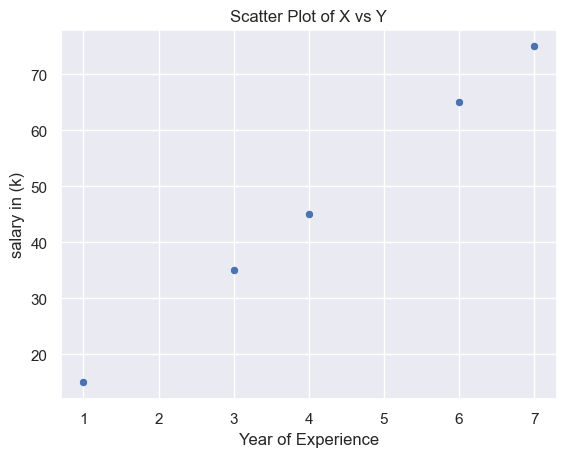

In [21]:
x=np.array([1, 3, 4, 6, 7])
y=np.array([15, 35, 45, 65, 75])

sns.scatterplot(x=x, y=y)
plt.xlabel('Year of Experience')
plt.ylabel('salary in (k)')
plt.title('Scatter Plot of X vs Y')
plt.show()

2.Prediction Function

In [26]:
def make_prediction(x, y, w, b):
    m=x.shape[0]
    pred_list = np.zeros((m, 1))
    for i in range(m):
        pred_list[i] = w * x[i] + b
    return pred_list

Predictions: [[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


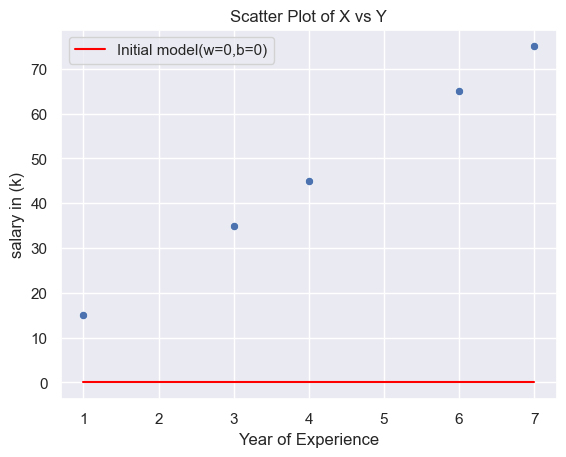

In [36]:
predictions=make_prediction(x, y, 0, 0)
print(f"Predictions: {predictions}")

sns.scatterplot(x=x, y=y)
plt.plot(x, predictions, color='red',label='Initial model(w=0,b=0)')
plt.xlabel('Year of Experience')
plt.ylabel('salary in (k)')
plt.title('Scatter Plot of X vs Y')
plt.legend()
plt.show()

[[1.]
 [3.]
 [4.]
 [6.]
 [7.]]


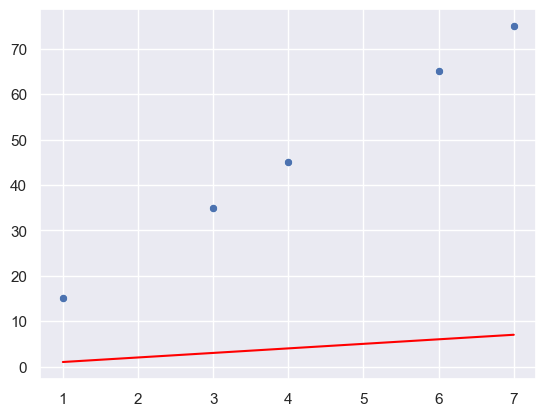

In [39]:
predictions=make_prediction(x, y, w=1, b=0)
print(predictions)

sns.scatterplot(x=x, y=y)
plt.plot(x, predictions, color='red')

Predictions: [[ 8.]
 [18.]
 [23.]
 [33.]
 [38.]]


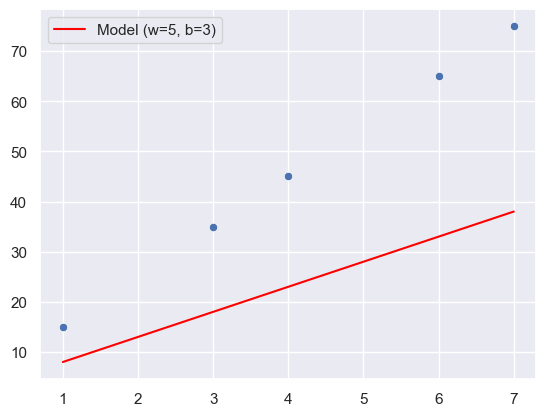

In [41]:
predictions=make_prediction(x, y, w=5, b=3)
print(f"Predictions: {predictions}")

sns.scatterplot(x=x, y=y)
plt.plot(x, predictions, color='red', label='Model (w=5, b=3)')
plt.legend()
plt.show()

3.Cost Function

In [42]:
def compute_cost(x,y,w,b):
    m=x.shape[0]
    cost=0
    for i in range(m):
        prediction=w*x[i]+b
        error=prediction-y[i]
        error_scquared=error**2
        cost += error_scquared
    cost = cost / (2 * m)
    return cost

4.Visulizing the cost

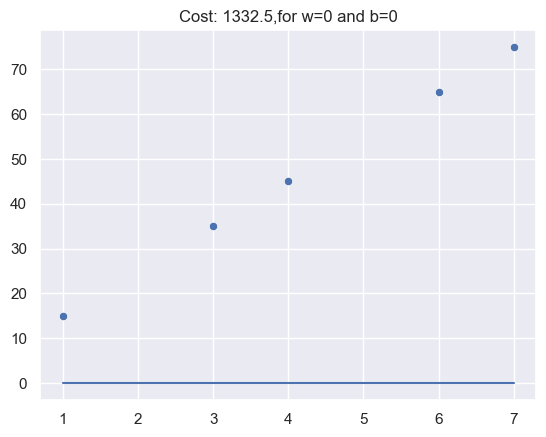

In [44]:
w=0
b=0
predictions=make_prediction(x, y, w, b)

sns.scatterplot(x=x, y=y)
plt.plot(x, predictions)
plt.title(f"Cost: {compute_cost(x,y,w,b)},for w={w} and b={b}")
plt.show()

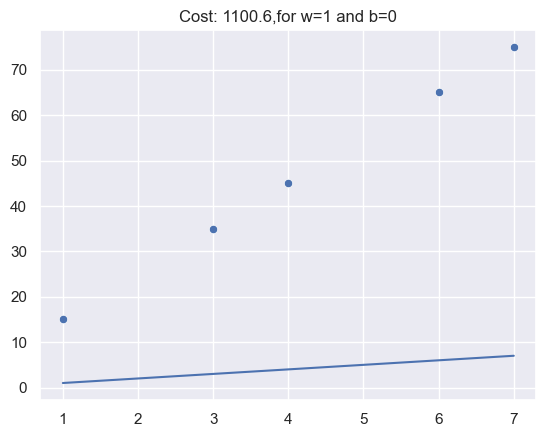

In [45]:
w=1
b=0
predictions=make_prediction(x, y, w, b)

sns.scatterplot(x=x, y=y)
plt.plot(x, predictions)
plt.title(f"Cost: {compute_cost(x,y,w,b)},for w={w} and b={b}")
plt.show()

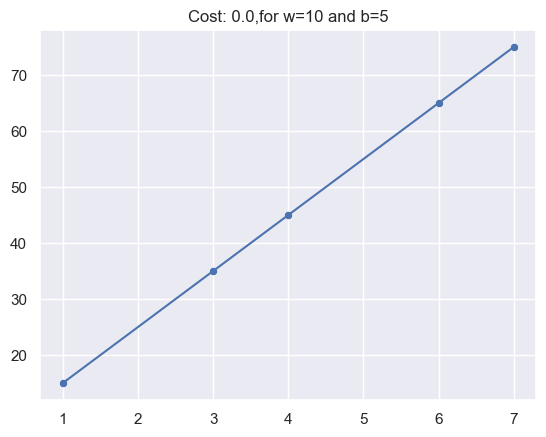

In [46]:
w=10
b=5
predictions=make_prediction(x, y, w, b)

sns.scatterplot(x=x, y=y)
plt.plot(x, predictions)
plt.title(f"Cost: {compute_cost(x,y,w,b)},for w={w} and b={b}")
plt.show()

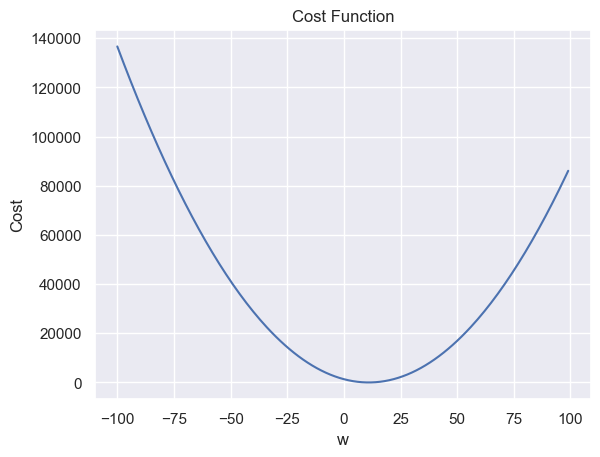

In [47]:
w_range=[]
cost_history=[]
for i in range(-100, 100):
    cost_i=compute_cost(x,y,w=i,b=0)
    w_range.append(i)
    cost_history.append(cost_i)
plt.plot(w_range, cost_history)
plt.xlabel('w')
plt.ylabel('Cost')
plt.title('Cost Function')
plt.show()


5.Gradient Descent

In [48]:
def calculate_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        prediction = w * x[i] + b
        error = prediction - y[i]
        dj_dw += error * x[i]
        dj_db += error
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_dw, dj_db

In [50]:
def gradient_descent(x, y, w_in, b_in, max_iter, alpha=0.01):
    w = w_in
    b = b_in
    cost_memo=[]
    iteration=[]
    for i in range(max_iter):
        dj_dw, dj_db = calculate_gradient(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost = compute_cost(x, y, w, b)
        cost_memo.append(cost)
        iteration.append(i)
        
        if i % 100 == 0:
            print(f"Cost after iteration {i}: {cost}")
    return w, b, cost_memo, iteration

Run Gradient Descent

In [52]:
W_final, b_final, cost_memo, iter_list = gradient_descent(x, y, w_in=0, b_in=0, max_iter=10000, alpha=0.01)

Cost after iteration 0: 790.37166
Cost after iteration 100: 0.6120066399205837
Cost after iteration 200: 0.41152019687322394
Cost after iteration 300: 0.2767108416610512
Cost after iteration 400: 0.1860635042327127
Cost after iteration 500: 0.12511120778477827
Cost after iteration 600: 0.0841261932473795
Cost after iteration 700: 0.05656740523574873
Cost after iteration 800: 0.038036564018722505
Cost after iteration 900: 0.025576216485816435
Cost after iteration 1000: 0.01719773766650803
Cost after iteration 1100: 0.011563953605493345
Cost after iteration 1200: 0.0077757333890743335
Cost after iteration 1300: 0.005228491206436205
Cost after iteration 1400: 0.003515696710254575
Cost after iteration 1500: 0.0023639942902225724
Cost after iteration 1600: 0.001589576537675792
Cost after iteration 1700: 0.0010688492690443647
Cost after iteration 1800: 0.0007187063553461223
Cost after iteration 1900: 0.0004832662941114963
Cost after iteration 2000: 0.00032495373011114657
Cost after iteration

6.Final Results & Prediction

Final parameters: w=10.00000000137122, b=4.999999992816854


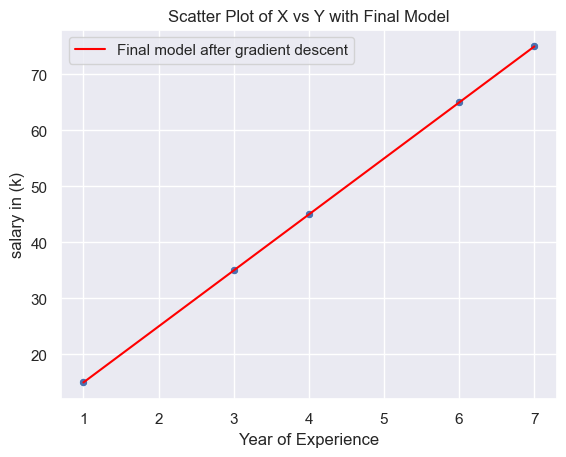

In [53]:
print(f"Final parameters: w={W_final}, b={b_final}")
final_predictions = make_prediction(x, y, W_final, b_final)

sns.scatterplot(x=x, y=y)
plt.plot(x, final_predictions, color='red', label='Final model after gradient descent')
plt.xlabel('Year of Experience')
plt.ylabel('salary in (k)')
plt.title('Scatter Plot of X vs Y with Final Model')
plt.legend()
plt.show()

#Example :Prediction salary for someone with 2 year of experience

In [55]:
x_new=2

prediction=W_final*x_new+b_final
print(f"Prediction for x={x_new}: {prediction:0.2f}")


Prediction for x=2: 25.00


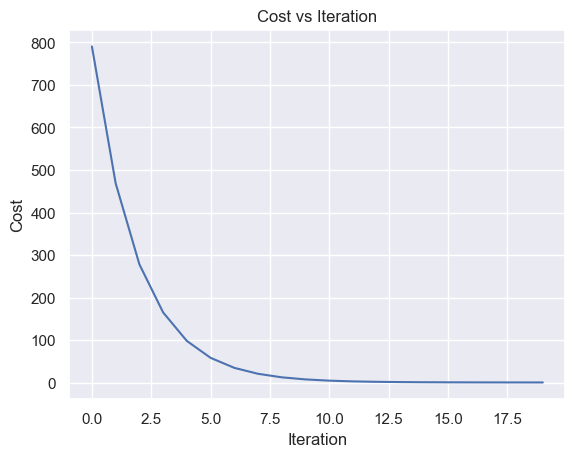

In [59]:
plt.plot(iter_list[:20], cost_memo[:20])
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.show()